# Task 1: Titanic Survival Prediction

### Objective
Build a machine learning model to predict whether a passenger on the Titanic survived or not.

### Dataset Features
The dataset contains the following features:
- `PassengerId`: Unique ID of each passenger
- `Survived`: Survival status (0 = No, 1 = Yes)
- `Pclass`: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
- `Name`: Name of the passenger
- `Sex`: Gender of the passenger
- `Age`: Age of the passenger
- `SibSp`: Number of siblings / spouses aboard the Titanic
- `Parch`: Number of parents / children aboard the Titanic
- `Ticket`: Ticket number
- `Fare`: Passenger fare
- `Cabin`: Cabin number
- `Embarked`: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)


In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set aesthetic styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


## 1. Load the Dataset

In [2]:
# Load dataset
df = pd.read_csv('data/titanic.csv')

# Display shape and first few rows
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset Shape: 891 rows, 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Inspection & Cleaning
Before training models, let's understand the data structure, types, and check for missing values.

In [3]:
# Information about data types and non-null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Check number of missing values per column
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

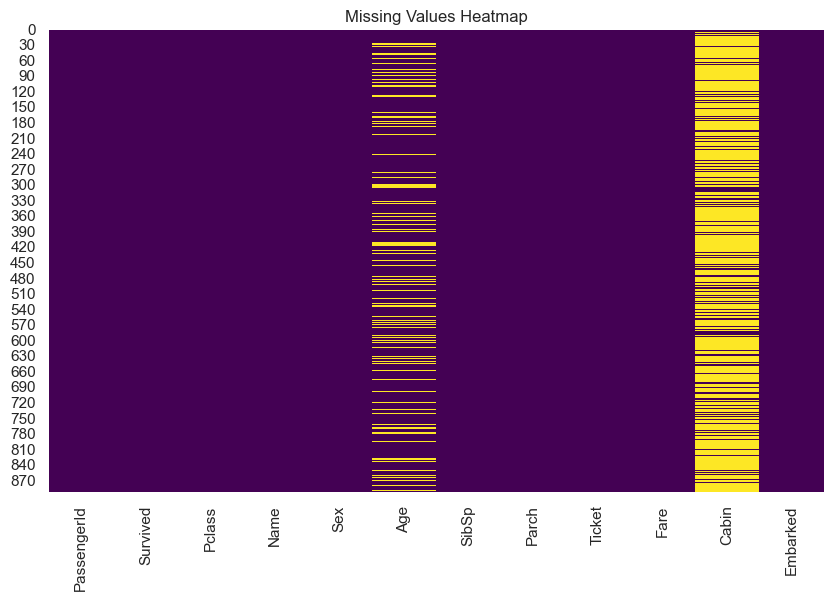

In [5]:
# Visualize missing values using heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


### Handling Missing Values:
1. **Age**: Has some missing values. We will fill them with the **median age** to avoid skewness.
2. **Embarked**: Has only 2 missing values. We will fill them with the **mode** (most frequent port, which is 'S').
3. **Cabin**: Over 77% of Cabin values are missing. We will **drop** this column as it contains too many missing values to be useful.
4. **PassengerId, Name, Ticket**: These are unique identifiers and text features that do not contribute to predicting survival. We will drop them.


In [6]:
# Impute missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop irrelevant/empty columns
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# Verify no missing values remain (except in target which is fully clean)
df.isnull().sum()


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)
Let's visualize relationships between features and passenger survival.

C:\Users\hp\AppData\Local\Temp\ipykernel_19816\375630735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Survived', data=df, palette='Set2')


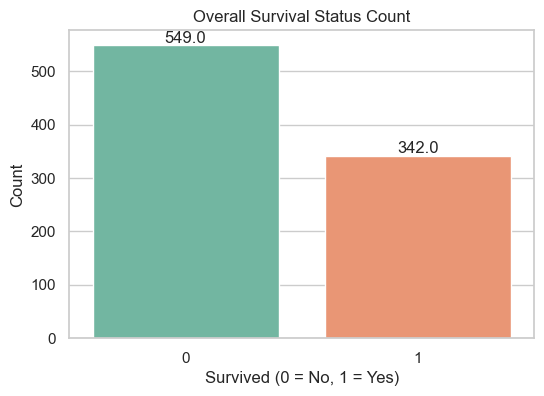

In [7]:
# Overall Survival Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Overall Survival Status Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Add labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()


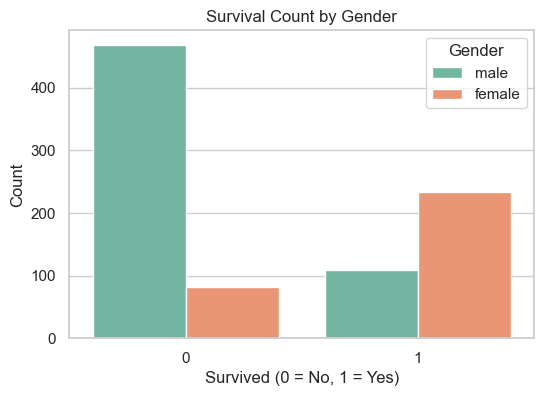

Female Survival Rate: 74.20%
Male Survival Rate: 18.89%


In [8]:
# Survival Rate by Sex
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', hue='Sex', data=df, palette='Set2')
plt.title('Survival Count by Gender')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

# Print survival percentage by sex
survival_sex = df.groupby('Sex')['Survived'].mean() * 100
print(f"Female Survival Rate: {survival_sex['female']:.2f}%")
print(f"Male Survival Rate: {survival_sex['male']:.2f}%")


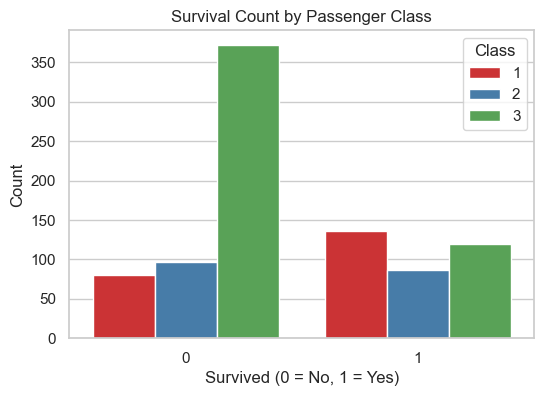

Class 1 Survival Rate: 62.96%
Class 2 Survival Rate: 47.28%
Class 3 Survival Rate: 24.24%


In [9]:
# Survival Rate by Passenger Class (Pclass)
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', hue='Pclass', data=df, palette='Set1')
plt.title('Survival Count by Passenger Class')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Class')
plt.show()

# Print survival percentage by class
survival_class = df.groupby('Pclass')['Survived'].mean() * 100
for c in survival_class.index:
    print(f"Class {c} Survival Rate: {survival_class[c]:.2f}%")


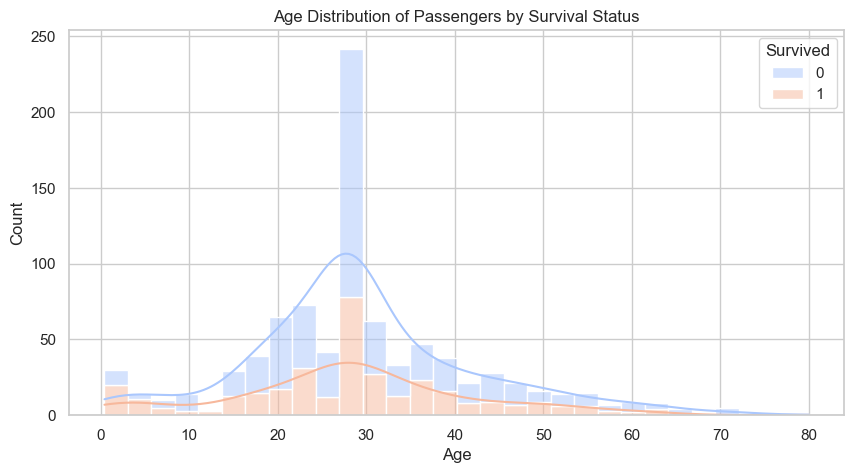

In [10]:
# Age distribution by survival status
plt.figure(figsize=(10, 5))
sns.histplot(x='Age', hue='Survived', data=df, kde=True, multiple='stack', palette='coolwarm')
plt.title('Age Distribution of Passengers by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


## 4. Feature Encoding & Correlation Analysis
We will encode categorical text features (`Sex` and `Embarked`) into numerical values to train our models.

In [11]:
# Encode categorical columns
label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex']) # female -> 0, male -> 1
df['Embarked'] = label_encoder.fit_transform(df['Embarked']) # C -> 0, Q -> 1, S -> 2

df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


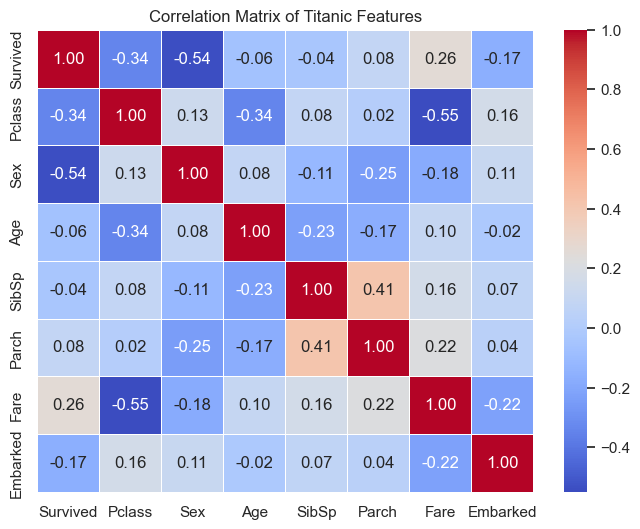

In [12]:
# Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Titanic Features')
plt.show()


## 5. Model Building & Training
We will split our data into training and test sets, scale the features, and train two classification models:
1. **Logistic Regression** (Linear Baseline)
2. **Random Forest Classifier** (Tree-based ensemble)


In [13]:
# Separate features and target variable
X = df.drop(columns=['Survived'])
y = df['Survived']

# Train-test split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features size: {X_train.shape}")
print(f"Testing features size: {X_test.shape}")


Training features size: (712, 7)
Testing features size: (179, 7)


In [14]:
# Feature scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Logistic Regression

In [15]:
# Initialize and train Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_lr = log_reg.predict(X_test_scaled)

# Calculate accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Test Accuracy: {acc_lr:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Logistic Regression Test Accuracy: 0.8045

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



### Random Forest Classifier

In [16]:
# Initialize and train Random Forest model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_rf = rf_clf.predict(X_test_scaled)

# Calculate accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Accuracy: {acc_rf:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Test Accuracy: 0.8212

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



## 6. Model Comparison & Confusion Matrix

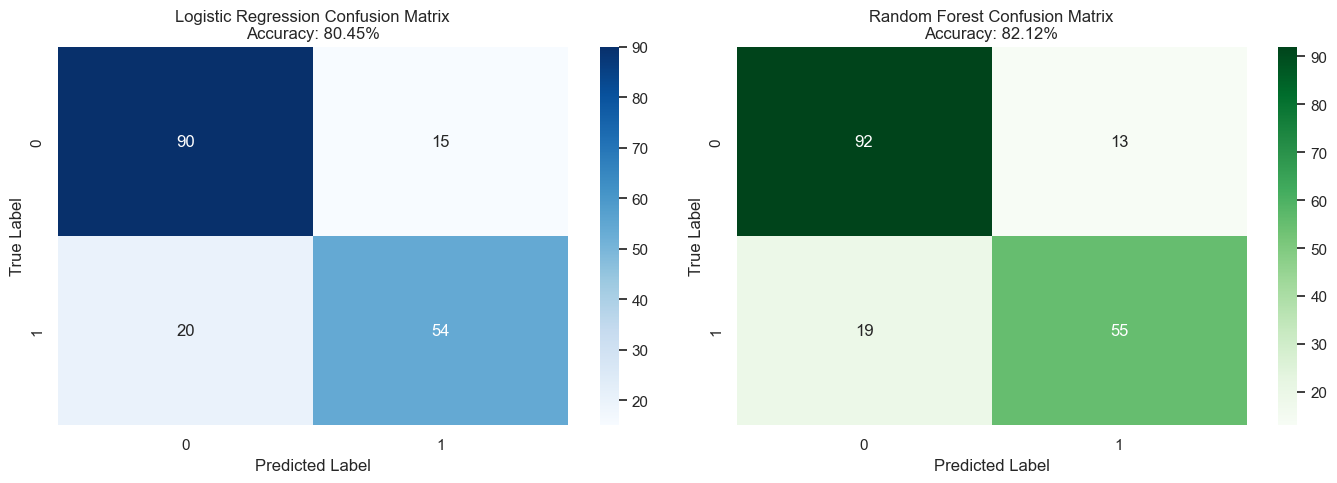

In [17]:
# Plot confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title(f'Logistic Regression Confusion Matrix\nAccuracy: {acc_lr:.2%}')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Random Forest Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title(f'Random Forest Confusion Matrix\nAccuracy: {acc_rf:.2%}')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


## 7. Feature Importance Analysis
Let's see which features played the most important role in predicting survival in the Random Forest model.

C:\Users\hp\AppData\Local\Temp\ipykernel_19816\2145600016.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


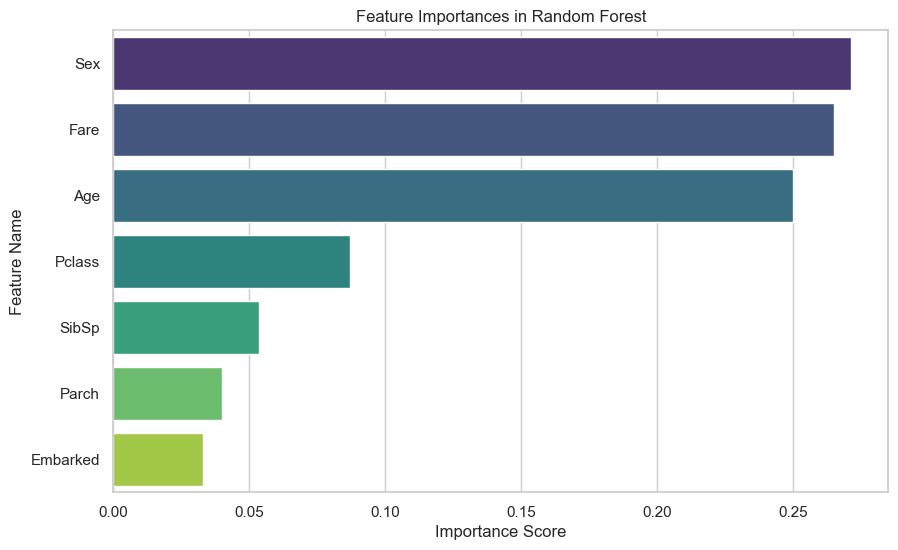

1. Sex: 0.2714
2. Fare: 0.2650
3. Age: 0.2500
4. Pclass: 0.0870
5. SibSp: 0.0537
6. Parch: 0.0399
7. Embarked: 0.0330


In [18]:
# Calculate and plot feature importances
importances = rf_clf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title('Feature Importances in Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

# Print values
for rank, idx in enumerate(indices, 1):
    print(f"{rank}. {feature_names[idx]}: {importances[idx]:.4f}")


## 8. Conclusion
1. **Key Insights**:
   - **Gender (`Sex`)** is by far the most significant factor in survival, which matches the historical practice of prioritizing women and children.
   - **Ticket Class (`Pclass`)** and **Fare** are also highly significant; passengers in 1st class (higher fare) had a significantly higher survival rate than those in 3rd class.
   - **Age** is another important feature, as younger children were prioritized.
2. **Model Performance**:
   - Both models performed well, achieving accuracy of ~80%+.
   - Random Forest generally performs slightly better or offers more robust handling of non-linear interactions compared to Logistic Regression.
